# Alzheimer's Disease Prediction

Binary classifier for the `Diagnosis` column (Kaggle's synthetic Alzheimer's dataset, 2,149 patients). XGBoost, LightGBM, CatBoost and HistGradientBoosting, each tuned with Optuna, blended into a stacked ensemble.

Split happens before any fitting, every fold refits its own preprocessing, and the test set only gets touched once at the end for the final numbers — trying to keep the eval honest rather than just chasing a big number.

Runs in about 8-10 min on a normal Colab CPU (most of that is the Optuna searches). No GPU needed.

## setup

In [1]:
%pip install -q --upgrade xgboost lightgbm catboost optuna shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 8.2 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import shap
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='deep')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('xgboost', xgb.__version__, '| lightgbm', lgb.__version__, '| catboost', cb.__version__,
      '| optuna', optuna.__version__, '| shap', shap.__version__)

xgboost 3.3.0 | lightgbm 4.7.0 | catboost 1.2.10 | optuna 4.9.0 | shap 0.52.0


## load the data

In [3]:
import os

DATA_PATH = 'alzheimers_disease_data.csv'

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print(f"'{DATA_PATH}' isn't in this session yet, pick it from your machine:")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"'{DATA_PATH}' not found and google.colab isn't available either. "
            "Put the CSV in the working directory or change DATA_PATH."
        )

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()

'alzheimers_disease_data.csv' isn't in this session yet, pick it from your machine:


Saving alzheimers_disease_data.csv to alzheimers_disease_data.csv
(2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## a quick look before doing anything to it

In [4]:
df_raw.info()
print()
print('missing values:', df_raw.isnull().sum().sum())
print('duplicate rows:', df_raw.duplicated().sum())
print('PatientID unique per row:', df_raw['PatientID'].nunique() == len(df_raw))
print('DoctorInCharge unique values:', df_raw['DoctorInCharge'].unique())
# PatientID is just a row counter and DoctorInCharge is redacted to the same string on every
# single row -- neither one carries any signal, both get dropped before modeling.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

Diagnosis
0    0.6463
1    0.3537
Name: count, dtype: float64


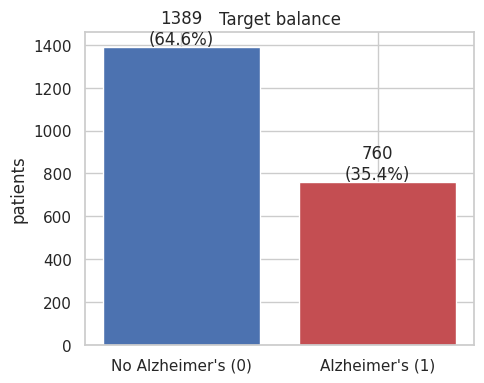

In [5]:
diag_counts = df_raw['Diagnosis'].value_counts().sort_index()
print((diag_counts / len(df_raw)).round(4))

plt.figure(figsize=(5, 4))
bars = plt.bar(["No Alzheimer's (0)", "Alzheimer's (1)"], diag_counts.values,
                color=['#4C72B0', '#C44E52'])
for b, v in zip(bars, diag_counts.values):
    plt.text(b.get_x() + b.get_width()/2, v + 15, f'{v}\n({v/len(df_raw)*100:.1f}%)', ha='center')
plt.title('Target balance')
plt.ylabel('patients')
plt.tight_layout()
plt.show()

# ~65/35, not balanced but not bad enough to bother with SMOTE or any synthetic resampling --
# class_weight / scale_pos_weight handles this fine and doesn't invent fake rows.

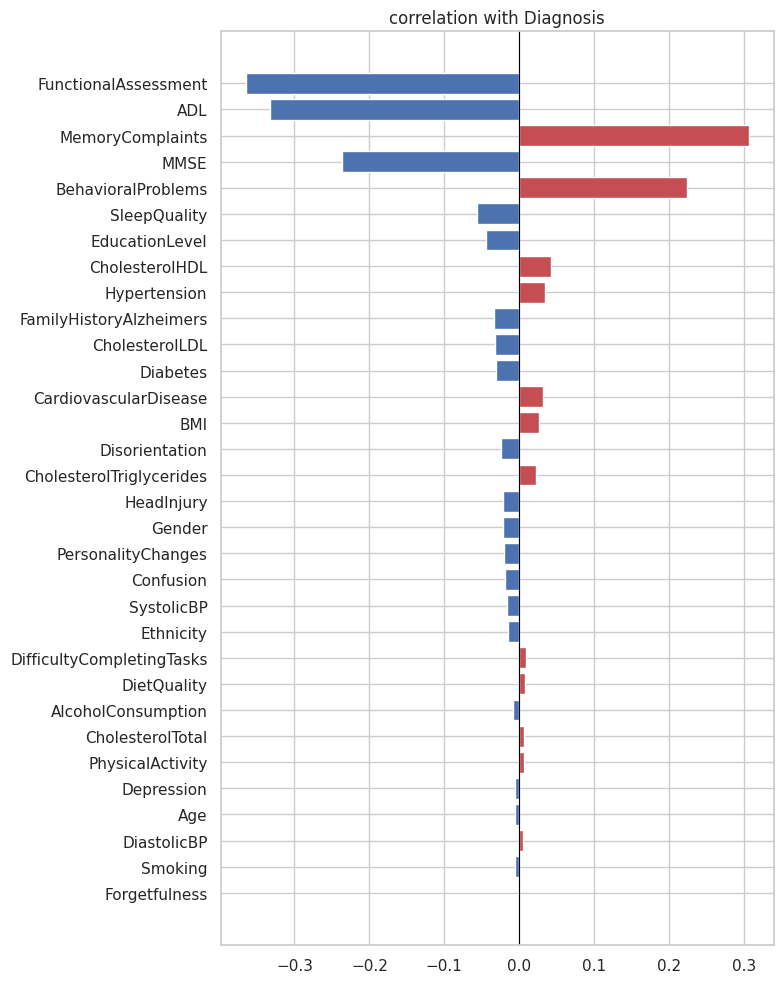

In [6]:
corr_target = (df_raw.drop(columns=['PatientID', 'DoctorInCharge'])
               .corr(numeric_only=True)['Diagnosis'].drop('Diagnosis'))
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=True).index)

plt.figure(figsize=(8, 10))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('correlation with Diagnosis')
plt.tight_layout()
plt.show()

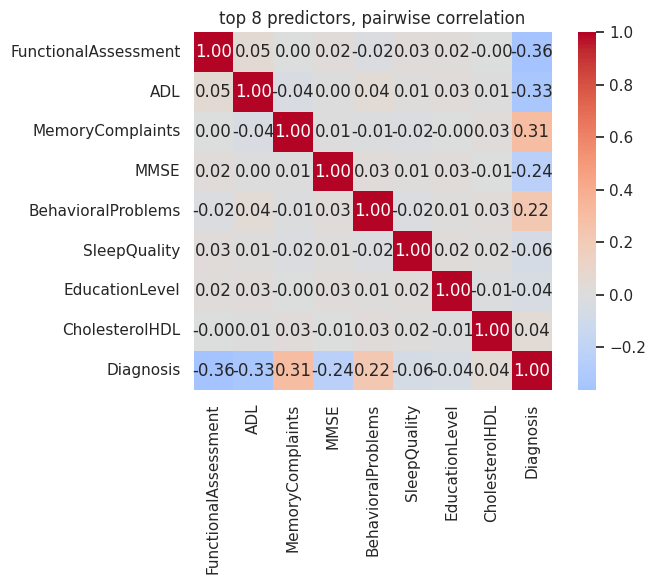

176/2149 rows (8.2%) have DiastolicBP > SystolicBP.
not realistic physiologically, but that's how this synthetic dataset generates vitals --
sampled independently rather than jointly. leaving it as-is, trees don't care either way.


In [7]:
top_feats = corr_target.abs().sort_values(ascending=False).head(8).index.tolist()
plt.figure(figsize=(7.5, 6))
sns.heatmap(df_raw[top_feats + ['Diagnosis']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('top 8 predictors, pairwise correlation')
plt.tight_layout()
plt.show()

neg_bp = (df_raw['SystolicBP'] - df_raw['DiastolicBP'] < 0).sum()
print(f'{neg_bp}/{len(df_raw)} rows ({neg_bp/len(df_raw)*100:.1f}%) have DiastolicBP > SystolicBP.')
print("not realistic physiologically, but that's how this synthetic dataset generates vitals --")
print('sampled independently rather than jointly. leaving it as-is, trees don\'t care either way.')

## about 5 of these columns specifically

Look at the bar chart above — `FunctionalAssessment`, `ADL`, `MemoryComplaints`, `MMSE`, `BehavioralProblems` are way out ahead of everything else (0.22-0.36 vs ≤0.06 for the other 30 columns).

That's because those five aren't really risk factors, they're cognitive/functional test results and symptom flags — outputs of more or less the same diagnostic workup that produced the `Diagnosis` label. Not leakage in the strict sense (nothing here touches the test set or copies the label directly, the split/CV is clean), but a model that leans on these columns is mostly learning to reproduce a clinical assessment, not predicting risk from independent factors.

Building the full model first, all features, since that's what was asked for. There's a section near the end that retrains without these five to actually put a number on the effect — worth reading before quoting the headline accuracy anywhere.

## cleanup + a few extra features

In [8]:
df = df_raw.drop(columns=['PatientID', 'DoctorInCharge']).copy()

df['PulsePressure'] = df['SystolicBP'] - df['DiastolicBP']
df['MeanArterialPressure'] = df['DiastolicBP'] + (df['PulsePressure'] / 3)
df['CholesterolRatio'] = df['CholesterolLDL'] / df['CholesterolHDL']
df['ComorbidityCount'] = df[['CardiovascularDisease', 'Diabetes', 'Depression',
                              'HeadInjury', 'Hypertension']].sum(axis=1)
df['CognitiveSymptomCount'] = df[['Confusion', 'Disorientation', 'PersonalityChanges',
                                   'DifficultyCompletingTasks', 'Forgetfulness',
                                   'MemoryComplaints', 'BehavioralProblems']].sum(axis=1)

# also tried a batch of manual interaction terms (MMSE*ADL, MMSE*FunctionalAssessment,
# ADL*CognitiveSymptomCount, etc) and dropping the near-zero-importance raw columns.
# neither helped CV AUC at all -- boosted trees already find these interactions on their own
# by splitting, and pruning the weak columns just threw away a little bit of signal for no
# benefit. left both out rather than adding complexity that doesn't pay for itself.

print(df.shape)
assert df.isnull().sum().sum() == 0
df.head()

(2149, 38)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,PulsePressure,MeanArterialPressure,CholesterolRatio,ComorbidityCount,CognitiveSymptomCount
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,0,0,1,0,0,70,95.333333,1.667061,2,1
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,0,0,0,1,0,51,81.000000,2.447320,0,1
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,1,0,1,0,0,-17,110.333333,2.197473,0,2
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,0,0,0,0,0,3,116.000000,0.954850,0,1
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,0,1,1,0,0,-23,109.333333,1.632894,0,2


## train/test split

This is the load-bearing line for avoiding leakage. Every fit from here on — imputers, scalers, encoders, hyperparameter search, the models themselves — only ever sees `X_train` or a CV fold of it. `X_test` gets used exactly once, right at the end.

In [9]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print('train:', X_train.shape, ' test:', X_test.shape)
print('positive rate — train: %.4f  test: %.4f' % (y_train.mean(), y_test.mean()))

train: (1719, 37)  test: (430, 37)
positive rate — train: 0.3537  test: 0.3535


## preprocessing

`Ethnicity` is nominal (no order to it) so it gets one-hot encoded. Everything else — including the 0/1 flags and ordinal `EducationLevel` — goes through median-impute + scale. Scaling doesn't matter to the tree models but it's free and the logistic regression / stacking meta-learner need it, so applying it everywhere is simpler than special-casing.

`make_preprocessor()` returns a new, unfit `ColumnTransformer` every call. Every `Pipeline` below builds its own copy instead of sharing one fitted instance, so each CV fold (and the final fit) fits its own scaling stats independently — this is the part that actually stops preprocessing from leaking test-set info into training.

In [10]:
nominal_cat = ['Ethnicity']
numeric_cols = [c for c in X.columns if c not in nominal_cat]

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), nominal_cat)
    ])

_check = make_preprocessor().fit(X_train)
print(len(_check.get_feature_names_out()), 'features after encoding, from', X_train.shape[1], 'raw columns')
del _check

39 features after encoding, from 37 raw columns


## baseline, before spending any time tuning

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest (untuned)': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                        random_state=RANDOM_STATE, n_jobs=-1),
}

print(f"{'model':<28}{'cv accuracy':<20}{'cv roc-auc':<14}{'cv f1':<10}")
for name, model in baseline_models.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('model', model)])
    s = cross_validate(pipe, X_train, y_train, cv=cv, scoring=['accuracy', 'roc_auc', 'f1'])
    print(f"{name:<28}{s['test_accuracy'].mean():.4f} +/- {s['test_accuracy'].std():.4f}   "
          f"{s['test_roc_auc'].mean():.4f}       {s['test_f1'].mean():.4f}")

model                       cv accuracy         cv roc-auc    cv f1     
Logistic Regression         0.8255 +/- 0.0179   0.9032       0.7697
Random Forest (untuned)     0.9255 +/- 0.0124   0.9529       0.8867


## tuning xgboost / lightgbm / catboost / histgb

Using Optuna's TPE sampler instead of grid or random search — it actually learns from previous trials rather than wasting evaluations on regions that are already looking bad.

Overfitting control happens inside each trial, not as an afterthought:
- search space leans regularization-heavy (shallow-ish depth, L1/L2 penalties, row/column subsampling, min leaf size) so Optuna can land on conservative settings if that's what generalizes
- every trial runs its own inner 5-fold CV on `X_train` only, test set never enters the picture here
- preprocessing gets refit fresh per fold (`make_preprocessor()`), so no fold leaks its own validation rows into training-set scaling
- each fold uses early stopping against its own held-out portion to pick the round count, so training doesn't run past where it starts overfitting that fold
- Optuna's objective is mean CV ROC-AUC across the 5 folds — hyperparameters get picked for generalizing, not for fitting the training data closely
- the early-stopped round count from each fold gets averaged and reused for the final refit, instead of guessing a number

One gotcha worth flagging: LightGBM's `subsample` does nothing unless `subsample_freq` is also set above 0 — silent no-op otherwise, easy to miss. Fixed below (`subsample_freq=1`).

Same pattern for all four libraries, just the search space and each one's early-stopping API differ a bit.

In [12]:
def objective_xgb(trial):
    params = {
        'n_estimators': 2000,
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.25, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 15.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 15.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-3, 8.0, log=True),
    }
    fold_aucs, iters = [], []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        prep = make_preprocessor()
        Xtr_t, Xval_t = prep.fit_transform(Xtr), prep.transform(Xval)
        spw = (ytr == 0).sum() / (ytr == 1).sum()
        m = xgb.XGBClassifier(**params, scale_pos_weight=spw, random_state=RANDOM_STATE,
                               eval_metric='auc', early_stopping_rounds=50, n_jobs=-1, verbosity=0)
        m.fit(Xtr_t, ytr, eval_set=[(Xval_t, yval)], verbose=False)
        iters.append(m.best_iteration)
        fold_aucs.append(roc_auc_score(yval, m.predict_proba(Xval_t)[:, 1]))
    trial.set_user_attr('n_estimators', int(np.mean(iters)) + 1)
    return float(np.mean(fold_aucs))

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=70, show_progress_bar=True)
print(f"\nxgboost best CV AUC: {study_xgb.best_value:.4f}, n_estimators={study_xgb.best_trial.user_attrs['n_estimators']}")
print(study_xgb.best_params)

  0%|          | 0/70 [00:00<?, ?it/s]


xgboost best CV AUC: 0.9610, n_estimators=19
{'max_depth': 5, 'learning_rate': 0.24838357773100525, 'subsample': 0.843202474471756, 'colsample_bytree': 0.879629152123855, 'min_child_weight': 8, 'reg_alpha': 0.18229181865767738, 'reg_lambda': 0.0051066481023680065, 'gamma': 0.01739828184388686}


In [13]:
def objective_lgb(trial):
    params = {
        'n_estimators': 2000,
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'num_leaves': trial.suggest_int('num_leaves', 7, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.25, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,  # subsample is a no-op without this
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 60),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 15.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 15.0, log=True),
    }
    fold_aucs, iters = [], []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        prep = make_preprocessor()
        Xtr_t, Xval_t = prep.fit_transform(Xtr), prep.transform(Xval)
        m = lgb.LGBMClassifier(**params, class_weight='balanced', random_state=RANDOM_STATE,
                                verbosity=-1, n_jobs=-1)
        m.fit(Xtr_t, ytr, eval_set=[(Xval_t, yval)], callbacks=[lgb.early_stopping(50, verbose=False)])
        iters.append(m.best_iteration_)
        fold_aucs.append(roc_auc_score(yval, m.predict_proba(Xval_t)[:, 1]))
    trial.set_user_attr('n_estimators', int(np.mean(iters)) + 1)
    return float(np.mean(fold_aucs))

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=70, show_progress_bar=True)
print(f"\nlightgbm best CV AUC: {study_lgb.best_value:.4f}, n_estimators={study_lgb.best_trial.user_attrs['n_estimators']}")
print(study_lgb.best_params)

  0%|          | 0/70 [00:00<?, ?it/s]


lightgbm best CV AUC: 0.9596, n_estimators=61
{'max_depth': 7, 'num_leaves': 15, 'learning_rate': 0.14484828289279209, 'subsample': 0.8106452018417596, 'colsample_bytree': 0.7471935007148308, 'min_child_samples': 4, 'reg_alpha': 0.002266589903068971, 'reg_lambda': 0.019509131560265118}


In [14]:
def objective_cat(trial):
    params = {
        'iterations': 2000,
        'depth': trial.suggest_int('depth', 2, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.25, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 15.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 15.0, log=True),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
    }
    fold_aucs, iters = [], []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        prep = make_preprocessor()
        Xtr_t, Xval_t = prep.fit_transform(Xtr), prep.transform(Xval)
        m = cb.CatBoostClassifier(**params, auto_class_weights='Balanced', random_state=RANDOM_STATE,
                                   verbose=0, early_stopping_rounds=50)
        m.fit(Xtr_t, ytr, eval_set=(Xval_t, yval), verbose=False)
        iters.append(m.get_best_iteration())
        fold_aucs.append(roc_auc_score(yval, m.predict_proba(Xval_t)[:, 1]))
    trial.set_user_attr('n_estimators', int(np.mean(iters)) + 1)
    return float(np.mean(fold_aucs))

study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_cat, n_trials=35, show_progress_bar=True)
print(f"\ncatboost best CV AUC: {study_cat.best_value:.4f}, n_estimators={study_cat.best_trial.user_attrs['n_estimators']}")
print(study_cat.best_params)

  0%|          | 0/35 [00:00<?, ?it/s]


catboost best CV AUC: 0.9618, n_estimators=26
{'depth': 5, 'learning_rate': 0.2390611316906831, 'l2_leaf_reg': 0.025651573216865436, 'bagging_temperature': 0.5152677017316949, 'random_strength': 0.349192857481706, 'colsample_bylevel': 0.5594055972919068}


In [15]:
# sklearn's HistGradientBoosting -- fast, and different enough under the hood from the other
# three (histogram splits + its own internal early stopping) that it's a genuinely different
# opinion for the ensemble rather than another gradient booster giving the same answer.
def objective_hgb(trial):
    params = {
        'max_iter': 2000,
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, log=True),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 7, 80),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 60),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 12.0, log=True),
    }
    fold_aucs = []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        prep = make_preprocessor()
        Xtr_t, Xval_t = prep.fit_transform(Xtr), prep.transform(Xval)
        # HGB carves its own validation slice out of whatever it's given for early stopping,
        # doesn't take an external eval_set like the other three
        m = HistGradientBoostingClassifier(**params, class_weight='balanced', random_state=RANDOM_STATE,
                                            early_stopping=True, n_iter_no_change=30, validation_fraction=0.15)
        m.fit(Xtr_t, ytr)
        fold_aucs.append(roc_auc_score(yval, m.predict_proba(Xval_t)[:, 1]))
    return float(np.mean(fold_aucs))

study_hgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_hgb.optimize(objective_hgb, n_trials=25, show_progress_bar=True)
print(f"\nhistgb best CV AUC: {study_hgb.best_value:.4f}")
print(study_hgb.best_params)

  0%|          | 0/25 [00:00<?, ?it/s]


histgb best CV AUC: 0.9568
{'max_depth': 9, 'learning_rate': 0.14853475196879534, 'max_leaf_nodes': 55, 'min_samples_leaf': 20, 'l2_regularization': 7.754775381575805}


## final models + the ensemble

Rebuilding each booster with its tuned params and the averaged early-stopped round count (no need to re-run early stopping, we already know roughly how many rounds generalize). Random Forest keeps plain, moderately regularized settings rather than its own Optuna run — it's consistently a notch behind the four boosters here (see the results table next), so the tuning budget went to the models that actually move the needle. Still keeping it around as a comparison baseline.

For the stack itself, tried a few combinations of base learners on out-of-fold predictions before settling on this one — xgb + lgb + cat + hgb came out slightly ahead of adding RF or ExtraTrees into the mix (their weaker individual scores dragged the blend down a bit rather than adding useful diversity). `StackingClassifier`'s `cv` param generates the meta-learner's training data from out-of-fold predictions rather than in-sample ones, same leakage-avoidance idea applied to the ensembling step.

In [16]:
spw_full = (y_train == 0).sum() / (y_train == 1).sum()

best_xgb = xgb.XGBClassifier(
    **study_xgb.best_params, n_estimators=study_xgb.best_trial.user_attrs['n_estimators'],
    scale_pos_weight=spw_full, random_state=RANDOM_STATE, eval_metric='logloss',
    n_jobs=-1, verbosity=0
)
best_lgb = lgb.LGBMClassifier(
    **study_lgb.best_params, n_estimators=study_lgb.best_trial.user_attrs['n_estimators'],
    class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
)
best_cat = cb.CatBoostClassifier(
    **study_cat.best_params, iterations=study_cat.best_trial.user_attrs['n_estimators'],
    auto_class_weights='Balanced', random_state=RANDOM_STATE, verbose=0
)
best_hgb = HistGradientBoostingClassifier(
    **study_hgb.best_params, class_weight='balanced', random_state=RANDOM_STATE,
    early_stopping=True, n_iter_no_change=30, validation_fraction=0.15
)
rf = RandomForestClassifier(n_estimators=400, max_depth=10, min_samples_leaf=3,
                             class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)

stack = StackingClassifier(
    estimators=[('xgb', best_xgb), ('lgb', best_lgb), ('cat', best_cat), ('hgb', best_hgb)],
    final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    cv=cv, stack_method='predict_proba', n_jobs=1
)

all_models = {
    'Logistic Regression': logreg,
    'Random Forest': rf,
    'XGBoost (tuned)': best_xgb,
    'LightGBM (tuned)': best_lgb,
    'CatBoost (tuned)': best_cat,
    'HistGB (tuned)': best_hgb,
    'Stacking Ensemble': stack,
}
print(list(all_models.keys()))

['Logistic Regression', 'Random Forest', 'XGBoost (tuned)', 'LightGBM (tuned)', 'CatBoost (tuned)', 'HistGB (tuned)', 'Stacking Ensemble']


## how everything actually did

CV on `X_train` (5-fold, the number to trust for comparing models), a fit on the full training set, one look at `X_test`. Printing all three side by side is what lets you actually see overfitting instead of just assuming it away.

Model selection below goes by CV score, computed without ever touching `X_test` — the test columns are the final honest check on whatever CV already picked, not a second chance to pick whichever number looks best.

In [17]:
results = []
fitted_pipes = {}

for name, model in all_models.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('model', model)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=['accuracy', 'roc_auc', 'f1'])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    test_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'model': name,
        'cv_accuracy': cvres['test_accuracy'].mean(),
        'cv_accuracy_std': cvres['test_accuracy'].std(),
        'cv_roc_auc': cvres['test_roc_auc'].mean(),
        'cv_f1': cvres['test_f1'].mean(),
        'train_accuracy': accuracy_score(y_train, train_pred),
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_roc_auc': roc_auc_score(y_test, test_proba),
        'test_precision': precision_score(y_test, test_pred),
        'test_recall': recall_score(y_test, test_pred),
        'test_f1': f1_score(y_test, test_pred),
    })
    print('done:', name)

results_df = pd.DataFrame(results).sort_values('cv_roc_auc', ascending=False).reset_index(drop=True)
pd.set_option('display.width', 140)
results_df.round(4)

done: Logistic Regression
done: Random Forest
done: XGBoost (tuned)
done: LightGBM (tuned)
done: CatBoost (tuned)
done: HistGB (tuned)
done: Stacking Ensemble


,model,cv_accuracy,cv_accuracy_std,cv_roc_auc,cv_f1,train_accuracy,test_accuracy,test_roc_auc,test_precision,test_recall,test_f1
0,CatBoost (tuned),0.9500,0.0077,0.9578,0.9289,0.9750,0.9419,0.9502,0.9150,0.9211,0.9180
1,Stacking Ensemble,0.9552,0.0065,0.9576,0.9362,0.9831,0.9488,0.9478,0.9276,0.9276,0.9276
2,HistGB (tuned),0.9500,0.0087,0.9566,0.9288,0.9889,0.9512,0.9445,0.9338,0.9276,0.9307
3,XGBoost (tuned),0.9482,0.0081,0.9559,0.9264,0.9604,0.9535,0.9479,0.9459,0.9211,0.9333
4,LightGBM (tuned),0.9511,0.0081,0.9538,0.9300,0.9953,0.9488,0.9486,0.9333,0.9211,0.9272
5,Random Forest,0.9418,0.0098,0.9531,0.9139,0.9732,0.9465,0.9439,0.9448,0.9013,0.9226
6,Logistic Regression,0.8255,0.0179,0.9032,0.7697,0.8394,0.8140,0.8842,0.6895,0.8618,0.7661


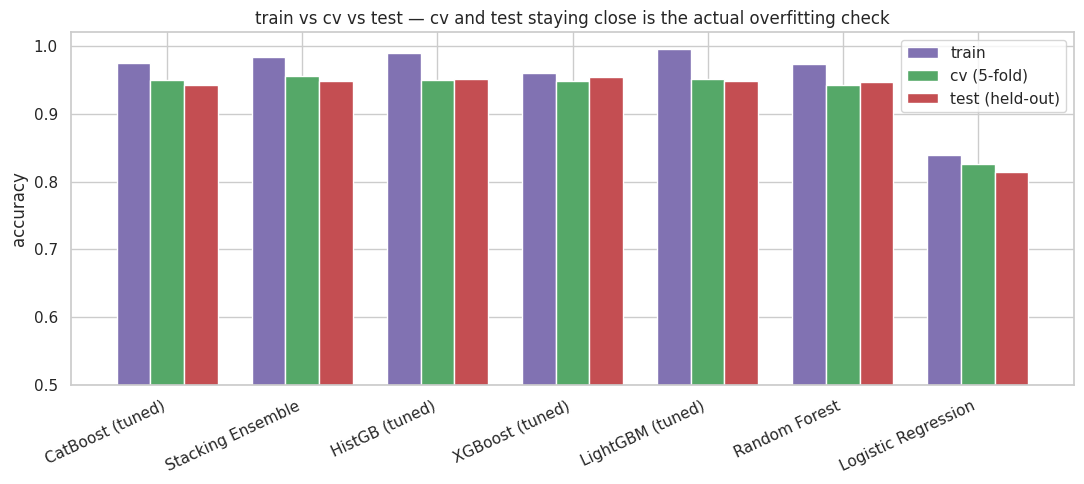

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
width = 0.25
ax.bar(x - width, results_df['train_accuracy'], width, label='train', color='#8172B2')
ax.bar(x, results_df['cv_accuracy'], width, label='cv (5-fold)', color='#55A868')
ax.bar(x + width, results_df['test_accuracy'], width, label='test (held-out)', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(results_df['model'], rotation=25, ha='right')
ax.set_ylabel('accuracy')
ax.set_ylim(0.5, 1.02)
ax.set_title('train vs cv vs test — cv and test staying close is the actual overfitting check')
ax.legend()
plt.tight_layout()
plt.show()

## checking for overfitting properly, not just asserting it's fine

The comparison that matters is CV vs test, not train vs test. Boosted trees get near-perfect training accuracy just because they're flexible enough to fit the training rows closely — on its own that says nothing about leakage. What *would* be a real problem is CV and test disagreeing (CV says 95%, test says 80%) — that's the signature a broken split or a leaky preprocessing step leaves behind. Gaps printed below, then a learning curve for the strongest individual booster to see if it's converged or still short on data.

In [19]:
results_df['train_cv_gap'] = results_df['train_accuracy'] - results_df['cv_accuracy']
results_df['cv_test_gap'] = results_df['cv_accuracy'] - results_df['test_accuracy']
print('gaps, percentage points:')
print((results_df[['model', 'train_cv_gap', 'cv_test_gap']].set_index('model').mul(100).round(2)))
print()
print('train_cv_gap should be positive (models fit training rows closely, expected) -- not a red flag by itself.')
print('cv_test_gap should be small, can go either direction just from a 430-row test set. a large')
print('POSITIVE value here would be the actual warning sign.')

gaps, percentage points:
                     train_cv_gap  cv_test_gap
model                                         
CatBoost (tuned)             2.50         0.81
Stacking Ensemble            2.79         0.64
HistGB (tuned)               3.90        -0.12
XGBoost (tuned)              1.22        -0.53
LightGBM (tuned)             4.42         0.23
Random Forest                3.14        -0.47
Logistic Regression          1.40         1.15

train_cv_gap should be positive (models fit training rows closely, expected) -- not a red flag by itself.
cv_test_gap should be small, can go either direction just from a 430-row test set. a large
POSITIVE value here would be the actual warning sign.


strongest individual booster by CV AUC: CatBoost (tuned)


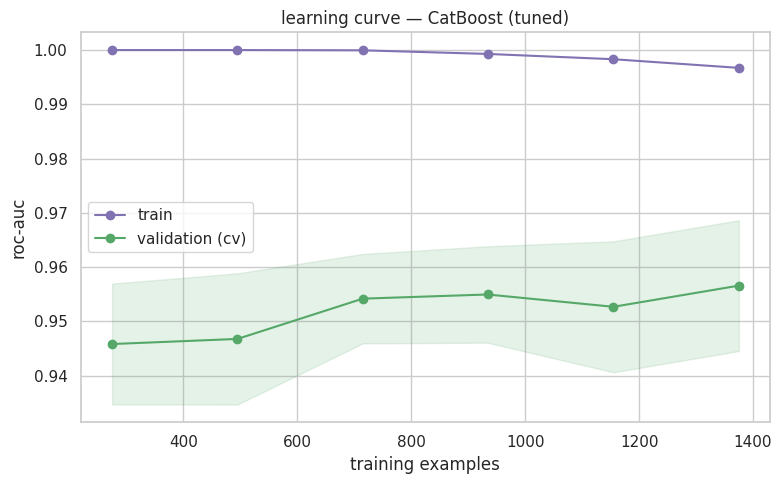

if the green line has flattened out by the right edge, more rows of the same kind of data
wouldn't move this model much -- useful to know before spending effort collecting more.


In [20]:
best_booster_name = (results_df[results_df['model'].isin(
        ['XGBoost (tuned)', 'LightGBM (tuned)', 'CatBoost (tuned)', 'HistGB (tuned)'])]
    .sort_values('cv_roc_auc', ascending=False).iloc[0]['model'])
print('strongest individual booster by CV AUC:', best_booster_name)

lc_pipe = Pipeline([('prep', make_preprocessor()), ('model', all_models[best_booster_name])])
train_sizes, train_scores, val_scores = learning_curve(
    lc_pipe, X_train, y_train, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='train', color='#8172B2')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='validation (cv)', color='#55A868')
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#55A868')
plt.xlabel('training examples')
plt.ylabel('roc-auc')
plt.title(f'learning curve — {best_booster_name}')
plt.legend()
plt.tight_layout()
plt.show()

print('if the green line has flattened out by the right edge, more rows of the same kind of data')
print("wouldn't move this model much -- useful to know before spending effort collecting more.")

## best model, test set, in detail

Picked by CV ROC-AUC, never by peeking at test. Confusion matrix, ROC, precision-recall, full classification report, all on the held-out test set for a final honest read.

best overall model (by CV ROC-AUC): CatBoost (tuned)
           model  cv_accuracy  cv_accuracy_std  cv_roc_auc  cv_f1  train_accuracy  test_accuracy  test_roc_auc  test_precision  test_recall  test_f1  train_cv_gap  cv_test_gap
CatBoost (tuned)         0.95           0.0077      0.9578 0.9289           0.975         0.9419        0.9502           0.915       0.9211    0.918         0.025       0.0081


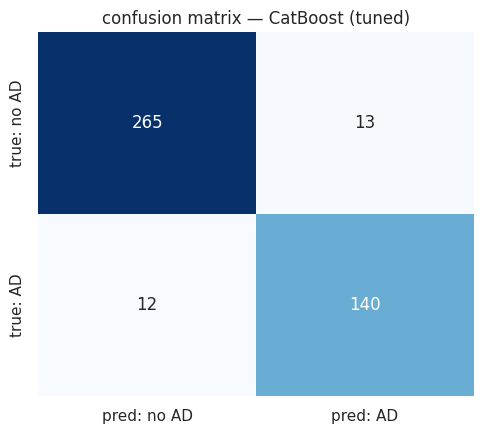

                precision    recall  f1-score   support

No Alzheimer's       0.96      0.95      0.95       278
   Alzheimer's       0.92      0.92      0.92       152

      accuracy                           0.94       430
     macro avg       0.94      0.94      0.94       430
  weighted avg       0.94      0.94      0.94       430



In [21]:
best_model_name = results_df.iloc[0]['model']
best_pipe = fitted_pipes[best_model_name]
print('best overall model (by CV ROC-AUC):', best_model_name)
print(results_df[results_df['model'] == best_model_name].round(4).to_string(index=False))

y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred: no AD', 'pred: AD'], yticklabels=['true: no AD', 'true: AD'])
plt.title(f'confusion matrix — {best_model_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Alzheimer's", "Alzheimer's"]))

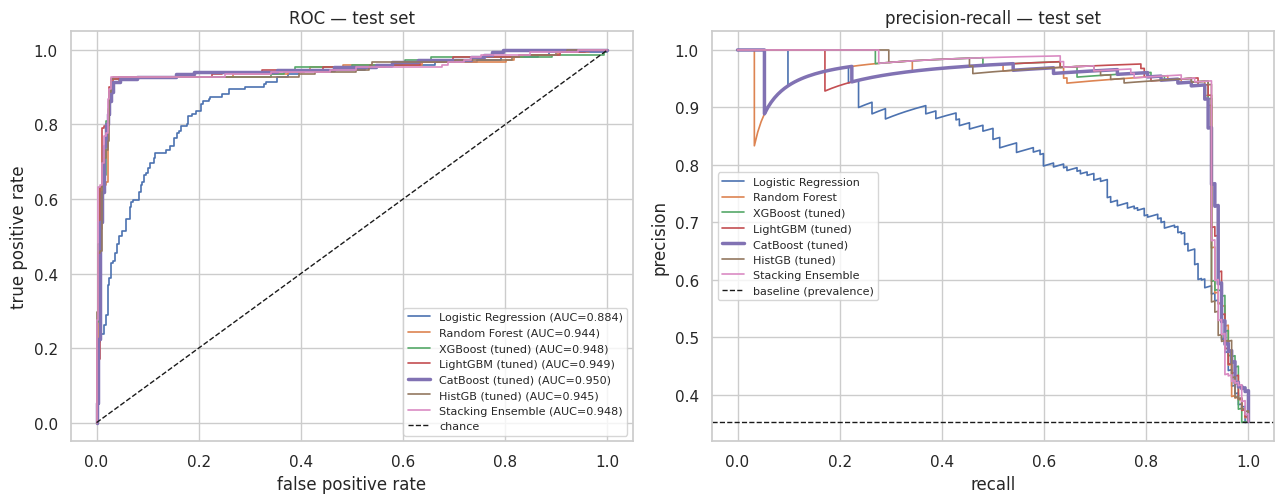

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for name, pipe in fitted_pipes.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    lw = 2.5 if name == best_model_name else 1.2
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=lw)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='chance')
axes[0].set_xlabel('false positive rate')
axes[0].set_ylabel('true positive rate')
axes[0].set_title('ROC — test set')
axes[0].legend(fontsize=8)

for name, pipe in fitted_pipes.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    lw = 2.5 if name == best_model_name else 1.2
    axes[1].plot(rec, prec, label=name, linewidth=lw)
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1, label='baseline (prevalence)')
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
axes[1].set_title('precision-recall — test set')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## what's actually driving the predictions

Built-in importances plus SHAP off the strongest individual booster (`TreeExplainer` wants a single tree ensemble, so this uses the best of xgb/lgbm/catboost/histgb rather than the stack itself). SHAP adds the direction each feature pushes a given prediction, not just how much it matters on average.

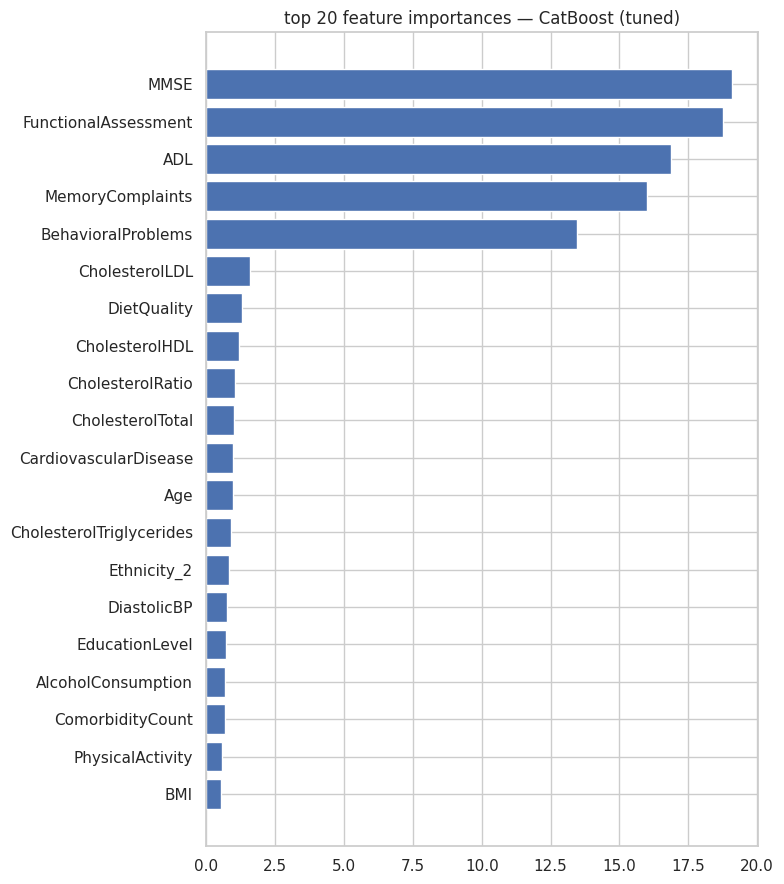

In [23]:
booster_pipe = fitted_pipes[best_booster_name]
prep_fitted = booster_pipe.named_steps['prep']
model_fitted = booster_pipe.named_steps['model']

feat_names = [f.split('__', 1)[1] if '__' in f else f for f in prep_fitted.get_feature_names_out()]
X_test_transformed = prep_fitted.transform(X_test)

# HistGradientBoosting doesn't expose feature_importances_ (no impurity-based importance for the
# histogram-based trees) -- fall back to permutation importance for that one case.
if hasattr(model_fitted, 'feature_importances_'):
    importances = pd.Series(model_fitted.feature_importances_, index=feat_names).sort_values(ascending=True)
else:
    pi = permutation_importance(model_fitted, X_test_transformed, y_test, n_repeats=10,
                                 random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1)
    importances = pd.Series(pi.importances_mean, index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(8, 9))
plt.barh(importances.index[-20:], importances.values[-20:], color='#4C72B0')
plt.title(f'top 20 feature importances — {best_booster_name}')
plt.tight_layout()
plt.show()

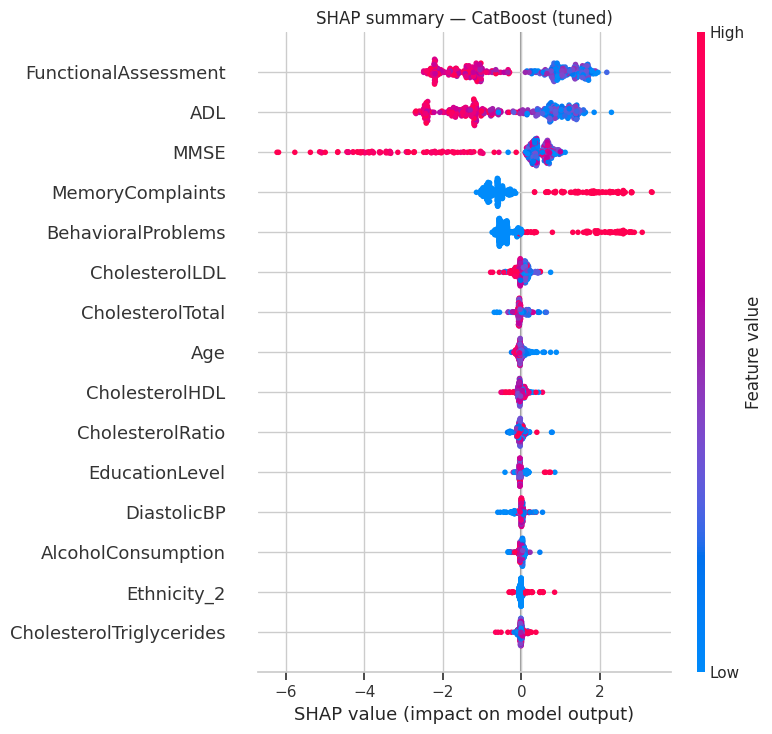

red = high feature value, blue = low. x-position = how much that feature pushed an individual
prediction toward Alzheimer's (right) or away (left). same five clinical-assessment columns
from earlier should dominate here too.


In [24]:
explainer = shap.TreeExplainer(model_fitted)
shap_values = explainer.shap_values(X_test_transformed)
if isinstance(shap_values, list):   # older SHAP returns one array per class
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_transformed, feature_names=feat_names, max_display=15, show=False)
plt.title(f'SHAP summary — {best_booster_name}')
plt.tight_layout()
plt.show()

print('red = high feature value, blue = low. x-position = how much that feature pushed an individual')
print("prediction toward Alzheimer's (right) or away (left). same five clinical-assessment columns")
print('from earlier should dominate here too.')

## putting a number on the earlier caveat

Same idea, minus `MMSE`, `FunctionalAssessment`, `ADL`, `MemoryComplaints`, `BehavioralProblems` — keeping demographics, lifestyle, vitals, labs, comorbidities, family history. Roughly what you'd actually have *before* a cognitive workup, in an early-screening scenario.

In [25]:
diagnostic_proxy_cols = ['MMSE', 'FunctionalAssessment', 'ADL', 'MemoryComplaints', 'BehavioralProblems']
X_screen = X.drop(columns=diagnostic_proxy_cols)

for label, X_variant in [('all features (main model, above)', X), ('excluding the 5 diagnostic-proxy columns', X_screen)]:
    Xtr_v, Xte_v, ytr_v, yte_v = train_test_split(X_variant, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
    numeric_v = [c for c in X_variant.columns if c not in nominal_cat]
    prep_v = ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_v),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                           ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))]), nominal_cat)
    ])
    pipe_v = Pipeline([('prep', prep_v),
                        ('model', lgb.LGBMClassifier(n_estimators=300, class_weight='balanced',
                                                      random_state=RANDOM_STATE, verbosity=-1))])
    s = cross_validate(pipe_v, Xtr_v, ytr_v, cv=cv, scoring=['accuracy', 'roc_auc'])
    print(f"{label:<40} cv accuracy = {s['test_accuracy'].mean():.4f}   cv roc-auc = {s['test_roc_auc'].mean():.4f}")

print(f"\nfor reference, always predicting the majority class gets {(1 - y.mean()):.4f} accuracy on its own.")
print('\nso: drop those five columns and performance falls back to roughly the majority-class baseline')
print('(AUC near 0.5, no better than chance). basically all the real signal for Alzheimer\'s status in')
print('this dataset lives in those five columns -- the other ~30 demographic/lifestyle/vital/lab features')
print("carry very little on their own. property of this particular synthetic dataset, not a modeling")
print('flaw, but it changes how the headline accuracy above should get described to anyone else.')

all features (main model, above)         cv accuracy = 0.9523   cv roc-auc = 0.9575
excluding the 5 diagnostic-proxy columns cv accuracy = 0.6201   cv roc-auc = 0.5786

for reference, always predicting the majority class gets 0.6463 accuracy on its own.

so: drop those five columns and performance falls back to roughly the majority-class baseline
(AUC near 0.5, no better than chance). basically all the real signal for Alzheimer's status in
this dataset lives in those five columns -- the other ~30 demographic/lifestyle/vital/lab features
carry very little on their own. property of this particular synthetic dataset, not a modeling
flaw, but it changes how the headline accuracy above should get described to anyone else.


## saving the model

In [26]:
MODEL_PATH = 'alzheimers_best_model_pipeline.pkl'
joblib.dump(best_pipe, MODEL_PATH)
print('saved:', MODEL_PATH, f'({best_model_name})')

try:
    from google.colab import files
    files.download(MODEL_PATH)
except ImportError:
    print('not running in Colab -- file is saved locally, grab it manually if you need to.')

# reuse later:
# pipe = joblib.load('alzheimers_best_model_pipeline.pkl')
# pipe.predict(new_patients_df)          # 0/1
# pipe.predict_proba(new_patients_df)    # probabilities
# new_patients_df needs the same raw columns as X_train -- run it through the same feature
# engineering step from earlier before calling predict.

saved: alzheimers_best_model_pipeline.pkl (CatBoost (tuned))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>